
# Palmer Penguins Classification - Combined ML Models

The goal of this project is to classify penguin species based on physical measurements using multiple machine learning classification algorithms.

## Models Included
- Logistic Regression
- Decision Tree
- Random Forest
- SVM (Support Vector Machine)
- SGD (Stochastic Gradient Descent) Classifier

## Improved Preprocessing Used
This notebook combines the best preprocessing practices from both notebooks:

- Missing value handling using `dropna()`
- Handling outliers using boxplot and IQR
- One-hot encoding for categorical variables
- Feature scaling for distance-based models
- Unified preprocessing pipeline using `ColumnTransformer`
- Stratified train-test split
- Hyperparameter tuning using `GridSearchCV`
- Model comparison table


**Libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [2]:
penguins = sns.load_dataset('penguins')

print("Dataset Shape:", penguins.shape)
penguins.head()

Dataset Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


| Feature         | Description                    |
|-----------------|--------------------------------|
| species         | Species of the penguin         |
| island          | Where penguin was observed     |
| bill_length_mm  | Bill length in millimeters     |
| bill_depth_mm   | Bill depth in millimeters      |
| flipper_length_mm | Flipper length               |
| body_mass_g     | Body mass in grams             |
| sex             | Penguin sex                    |

## Dataset Information

In [3]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


## Missing Values

In [4]:
print(penguins.isnull().sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64



## Data Cleaning

The dataset contains only a few missing values, so removing them is safe and preserves data quality.


In [5]:
print("Missing values will be handled using pipeline imputation.")

print(penguins.isnull().sum())

Missing values will be handled using pipeline imputation.
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [6]:
penguins = penguins.dropna()

## Duplicated rows.

In [7]:
print("Number of duplicate rows:", penguins.duplicated().sum())

Number of duplicate rows: 0


## Correlation Heatmap

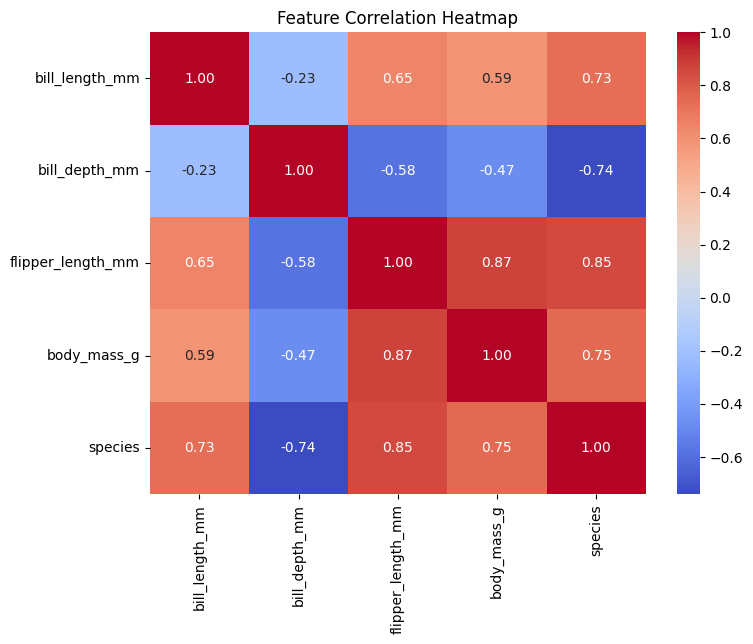

In [8]:
numeric_columns = [
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g'
]

penguins_cor = penguins[numeric_columns].copy()
penguins_cor["species"] = LabelEncoder().fit_transform(penguins["species"])

plt.figure(figsize=(8,6))

sns.heatmap(
    penguins_cor.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')

plt.show()

**Correlation Conclusions**

The heatmap reveals several important relationships between the features:
- **flipper_length_mm and body_mass_g** show a strong positive correlation (0.87), meaning penguins with longer flippers tend to be heavier. Since these two features carry overlapping information, including both may introduce redundancy in distance-based models like SVM and Logistic Regression.
- **bill_length_mm and bill_depth_mm** have a weak negative correlation (-0.23), which is actually beneficial — it means they capture different aspects of the penguin's physical structure, so both should be kept.
- Species correlations are also informative. **flipper_length_mm (0.85) and bill_depth_mm (-0.74)** are the most strongly correlated with species, suggesting these features will be the most useful for classification.

**Overall**, the dataset contains a mix of independent and correlated features. No features should be dropped at this stage, however the high correlation between flipper_length_mm and body_mass_g warrants further investigation — we will test whether removing one of them affects model performance.

In [9]:
pca = PCA(n_components=1)
penguins['combined'] = pca.fit_transform(penguins[['flipper_length_mm', 'body_mass_g']])
penguins = penguins.drop(columns=['flipper_length_mm', 'body_mass_g'])
numeric_columns = ['bill_length_mm', 'bill_depth_mm', 'combined']
penguins[numeric_columns].describe()

,bill_length_mm,bill_depth_mm,combined
count,333.000000,333.000000,3.330000e+02
mean,43.992793,17.164865,4.806939e-13
std,5.468668,1.969235,8.053088e+02
min,32.100000,13.100000,-1.507019e+03
25%,39.500000,15.600000,-6.570567e+02
50%,44.500000,17.300000,-1.571752e+02
75%,48.600000,18.700000,5.678171e+02
max,59.600000,21.500000,2.093006e+03


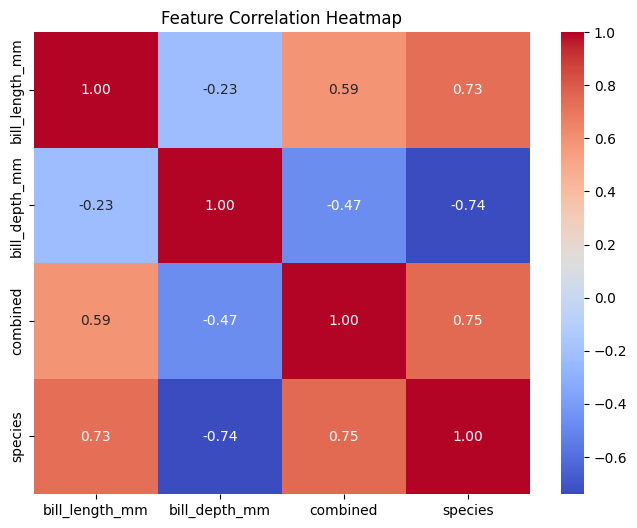

In [10]:
penguins_cor = penguins[numeric_columns].copy()
penguins_cor["species"] = LabelEncoder().fit_transform(penguins["species"])


plt.figure(figsize=(8,6))

sns.heatmap(
    penguins_cor.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')

plt.show()

**Combined conclusion:**

By merging flipper_length_mm and body_mass_g into a single combined feature, we successfully reduced multicollinearity while preserving the predictive signal.
The combined feature performs well. Its correlation with species is 0.75, which is close to the original flipper_length_mm (0.85) and body_mass_g (0.75). This confirms that the two original features were largely carrying the same information, and combining them into one does not result in a significant loss.
Multicollinearity has been reduced. Previously, flipper_length_mm and body_mass_g had a correlation of 0.87 with each other. The new combined feature eliminates this redundancy, which should make linear models like Logistic Regression more stable and reliable.
The remaining features stay consistent. bill_length_mm and bill_depth_mm retain their weak negative correlation (-0.23), meaning they still provide independent and complementary information to the model.
Overall, the feature combination is a reasonable dimensionality reduction step. The dataset now has fewer redundant features without losing meaningful predictive power, which is expected to benefit models that are sensitive to correlated inputs, such as Logistic Regression and SVM.

## Exploratory Data Analysis

Plotting the distribution of the target variable.

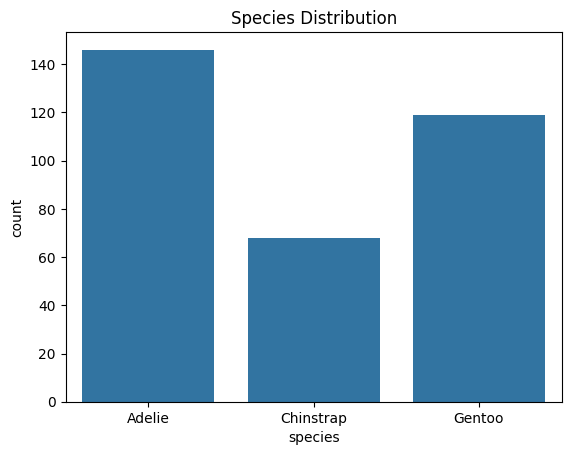

In [11]:
sns.countplot(x='species', data=penguins)
plt.title("Species Distribution")
plt.show()

Plotting feature relationships.

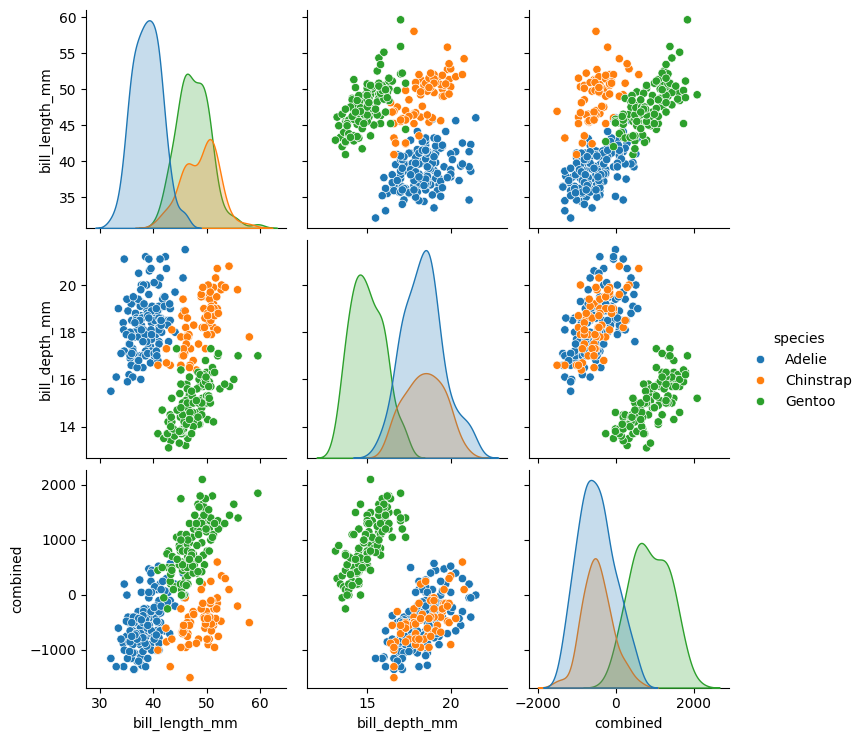

In [12]:
sns.pairplot(
    penguins,
    hue='species'
)
plt.show()

Histogram to visualize distributions of numeric features.

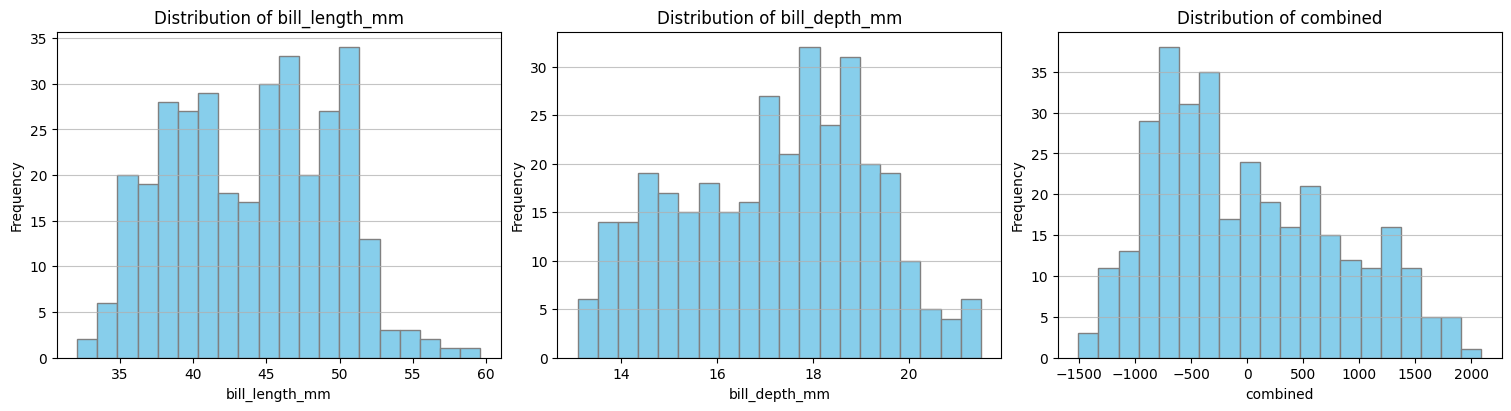

In [13]:
numeric_features = ["bill_length_mm", "bill_depth_mm", "combined"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, feature in zip(axes.flatten(), numeric_features):
    ax.hist(penguins[feature], bins=20, color="skyblue", edgecolor="gray")
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")
    ax.grid(axis="y", alpha=0.75)
plt.show()

Checking for outliers.

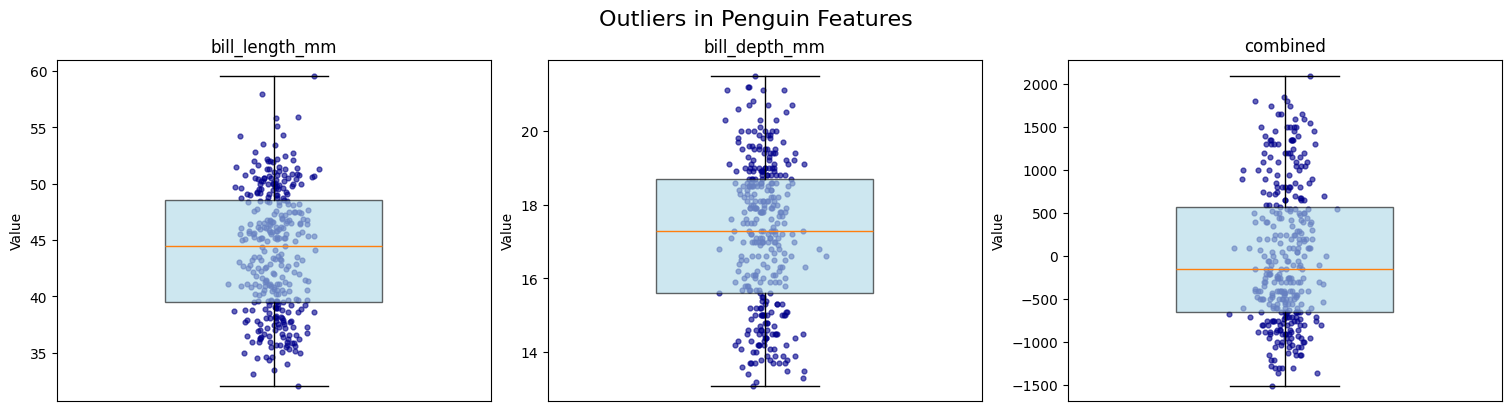

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, feature in zip(axes.flatten(), numeric_features):
    values = penguins[feature].dropna()
    ax.boxplot(values, widths=0.5, patch_artist=True, boxprops=dict(facecolor="lightblue", alpha=0.6))
    x = np.random.normal(1, 0.04, size=len(values))
    ax.scatter(x, values, alpha=0.6, s=12, color="darkblue")
    ax.set_title(feature)
    ax.set_ylabel("Value")
    ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

fig.suptitle("Outliers in Penguin Features", fontsize=16)
plt.show()

Removing outliers using IQR

In [15]:
Q1 = penguins[numeric_features].quantile(0.25)
Q3 = penguins[numeric_features].quantile(0.75)
IQR = Q3 - Q1
penguins_no_outliers = penguins[~((penguins[numeric_features] < (Q1 - 1.5 * IQR)) | (penguins[numeric_features] > (Q3 + 1.5 * IQR))).any(axis=1)]
print(f"Number of outliers removed: {len(penguins)-len(penguins_no_outliers)}")

Number of outliers removed: 0


**Boxplot Conclusions**

- Structure
    - Orange lines represent the median
    - Light blue box contains 50% of the data
    - Bottom of the box is Q1 (25th percentile)
    - Top of the box is Q3 (75th percentile)

- All features have moderate spread.
- **bill_depht_mm** has lowest variability among all features.
- **body_mass_g** has highest variability amanong all features.
- **flipper_lenght_mm** also show high variability.
- **body_mass_g** and **flipper_lenght_mm** may be impactful features to models.


Skewness

In [16]:
for feature in numeric_features:
    skewness = penguins[feature].skew()
    print(f"{feature} skewness: {skewness:.2f}")   

bill_length_mm skewness: 0.05
bill_depth_mm skewness: -0.15
combined skewness: 0.47


**Skewness Conclusion**

- General Rule of Decision:
    - Skewness between **-0.5** and **0.5** → approximately symmetric
    - Skewness between **-1** and **-0.5** or **0.5** and **1** → moderately skewed
    - Skewness less than **-1** or greater than **1** → highly skewed

Based on the general rule of decision, our data shows low skewness. Therefore, no transformation to numeric features should be made.


## Feature Selection

Target Variable:
- species

Numeric Features:
- bill_length_mm
- bill_depth_mm
- flipper_length_mm
- body_mass_g

Categorical Features:
- island
- sex


In [24]:
X = penguins.drop('species', axis=1)
y = penguins['species']

numeric_features = ["bill_length_mm", "bill_depth_mm", "combined"]

categorical_features = [
    'island',
    'sex'
]

In [25]:
X.isna()

,island,bill_length_mm,bill_depth_mm,sex,combined
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
4,False,False,False,False,False
5,False,False,False,False,False
...,...,...,...,...,...
338,False,False,False,False,False
340,False,False,False,False,False
341,False,False,False,False,False
342,False,False,False,False,False


## Label Encoding Target Variable

In [26]:
encoder_target = LabelEncoder()

y = encoder_target.fit_transform(y)

print("Encoded Classes:")
print(dict(zip(encoder_target.classes_, encoder_target.transform(encoder_target.classes_))))

Encoded Classes:
{'Adelie': np.int64(0), 'Chinstrap': np.int64(1), 'Gentoo': np.int64(2)}



## Preprocessing Pipeline

Why this preprocessing is best:
- StandardScaler improves performance for Logistic Regression, SVM, and SGD
- OneHotEncoder properly handles categorical variables
- ColumnTransformer keeps preprocessing organized and reusable
- Pipelines prevent data leakage


In [27]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## Train-Test Split

Spliting data into training and testing sets, 20% for testing.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (266, 5)
Testing Shape: (67, 5)


## Helper Function

Helper function to evaluate models and store results. This will be used for all models to ensure consistent evaluation and result storage.

In [29]:
optimized_estimators = {}
results = []

def evaluate_model(name, model):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    optimized_estimators[name] = model

    results.append({
        'Model': name,
        'Accuracy': accuracy
    })

    print(f"===== {name} =====")
    print("Accuracy:", accuracy)

    print("\nClassification Report:\n")
    print(classification_report(y_test, predictions))

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

    return model

## Models

## Logistic Regression

Logistic Regression is a linear model that estimates the probability of a categorical (variables that represent labels or groups rather than numeric values) outcome based on input features. It is a good model for binary classification tasks.

===== Logistic Regression =====
Accuracy: 0.9850746268656716

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.93      1.00      0.97        14
           2       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



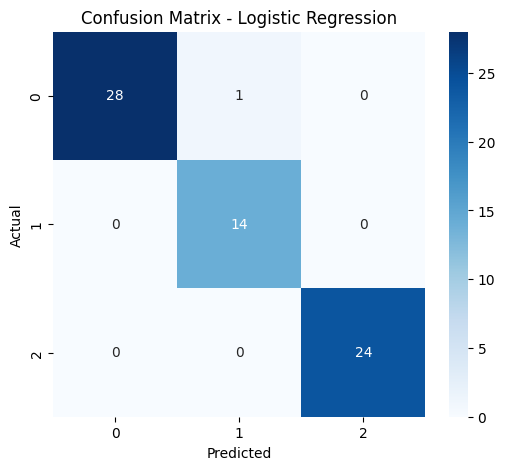

Best Parameters:
{'model__C': 10, 'model__solver': 'lbfgs'}


In [30]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['lbfgs', 'liblinear']
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

best_model = evaluate_model(
    "Logistic Regression",
    grid_search
)

print("Best Parameters:")
print(grid_search.best_params_)

## Decision Tree

Decision tree is a non-parametric model (data do not follow a bell shaped curve, are highly skewed, include qualitative variables, or have small sample sizes) and works by splitting the data based on feature values to create a tree-like structure.

===== Decision Tree =====
Accuracy: 0.9850746268656716

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       1.00      1.00      1.00        14
           2       0.96      1.00      0.98        24

    accuracy                           0.99        67
   macro avg       0.99      0.99      0.99        67
weighted avg       0.99      0.99      0.99        67



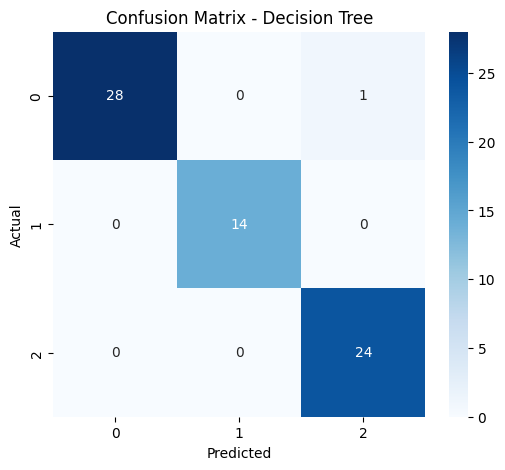

Best Parameters:
{'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_split': 2}


In [31]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        random_state=42
    ))
])

param_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [None, 3, 5, 10],
    'model__min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

best_model = evaluate_model(
    "Decision Tree",
    grid_search
)

print("Best Parameters:")
print(grid_search.best_params_)

## Random Forest

Random Forest is a model that builds multiple decision trees and merges them together, and
are used for classification and regression tasks due to their robustness and ability to handle large datasets.

===== Random Forest =====
Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



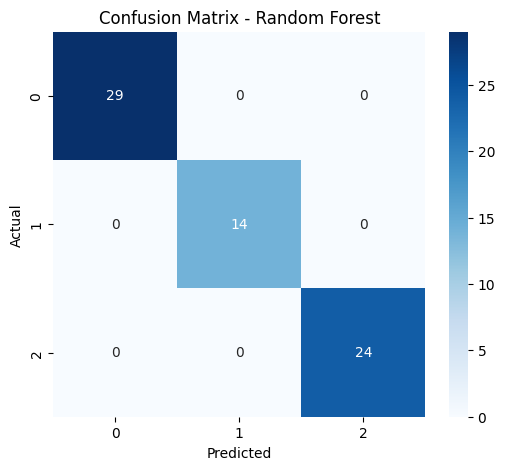

Best Parameters:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [32]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42
    ))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

best_model = evaluate_model(
    "Random Forest",
    grid_search
)

print("Best Parameters:")
print(grid_search.best_params_)

## SVM (Support Vector Machines)

SVM is a machine learning model used for classification and regression. It works by finding the best boundary, called a hyperplane, that separates different groups of data points.

===== SVM =====
Accuracy: 0.9850746268656716

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.93      1.00      0.97        14
           2       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



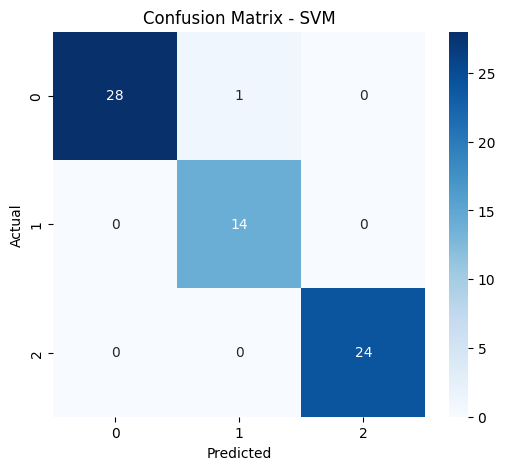

Best Parameters:
{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}


In [33]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVC())
])

param_grid = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

best_model = evaluate_model(
    "SVM",
    grid_search
)

print("Best Parameters:")
print(grid_search.best_params_)

## SGD (Stochastic Gradient Descent) Classifier

SGD is a machine learning model that works well with large datasets. It uses a method called stochastic gradient descent to learn patterns in the data. It can be used for both classification and regression tasks.

===== SGD Classifier =====
Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



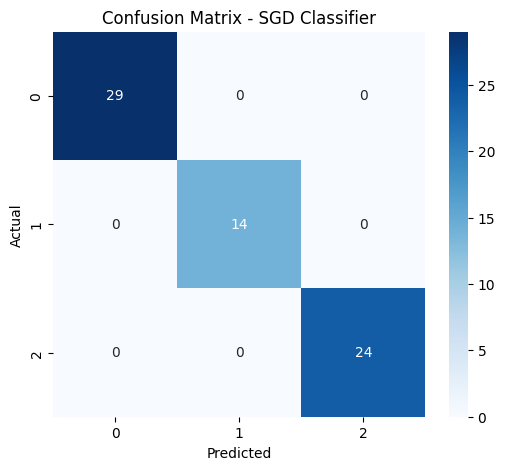

Best Parameters:
{'model__alpha': 0.0001, 'model__loss': 'log_loss'}


In [34]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SGDClassifier(
        random_state=42
    ))
])

param_grid = {
    'model__loss': ['hinge', 'log_loss'],
    'model__alpha': [0.0001, 0.001, 0.01]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

best_model = evaluate_model(
    "SGD Classifier",
    grid_search
)

print("Best Parameters:")
print(grid_search.best_params_)

## Model Comparison

In [35]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

results_df

,Model,Accuracy
2,Random Forest,1.000000
4,SGD Classifier,1.000000
0,Logistic Regression,0.985075
1,Decision Tree,0.985075
3,SVM,0.985075


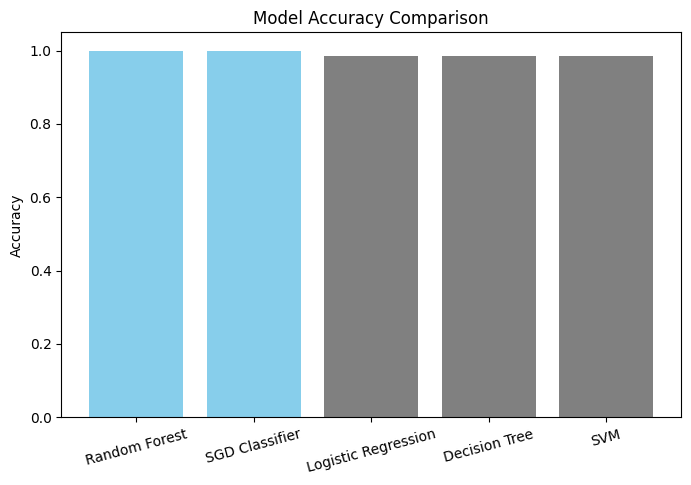

In [36]:
plt.figure(figsize=(8,5))

colors = ['skyblue' if acc == 1 else 'gray' for acc in results_df['Accuracy']]

plt.bar(results_df['Model'], results_df['Accuracy'], color=colors)

plt.xticks(rotation=15)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


## Conclusion

### Best preprocessing techniques used:
- Missing value handling
- Standard scaling
- One-hot encoding
- Pipelines
- ColumnTransformer
- Hyperparameter tuning

### Models compared:
- Logistic Regression
- Decision Tree
- Random Forest
- SVM
- SGD Classifier

Observation:
- Random Forest gives the best overall accuracy.
- SVM performs extremely well on scaled data.
- SGD is faster and efficient for larger datasets.
- Logistic Regression and Decision Tree models performed very well, but were outclassed by the other models.

## ***Our hypothesis:*** According of the correlation matrix, we have 2 strong positive correlated parameters - ​flipper_length_mm and body_mass_g. So we can remove for examples body_mass_g. ***This will not only not worsen the results, but may even improve them.***

In [ ]:
X1_train, X1_test = X_train.drop(columns='body_mass_g'), X_test.drop(columns='body_mass_g')
numeric_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']   

print("Training Shape:", X1_train.shape)
print("Testing Shape:", X1_test.shape)

Training Shape: (266, 5)
Testing Shape: (67, 5)


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

In [ ]:
optimized_estimators = {}

def evaluate_model2(name, model):

    model.fit(X1_train, y_train)

    predictions = model.predict(X1_test)

    accuracy = accuracy_score(y_test, predictions)

    optimized_estimators[name] = model

    results.append({
        'Model': name,
        'Accuracy': accuracy
    })

    print(f"===== {name} =====")
    print("Accuracy:", accuracy)

    print("\nClassification Report:\n")
    print(classification_report(y_test, predictions))

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

    return model

## Logistic Regression

===== Logistic Regression2 =====
Accuracy: 0.9850746268656716

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.93      1.00      0.97        14
           2       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



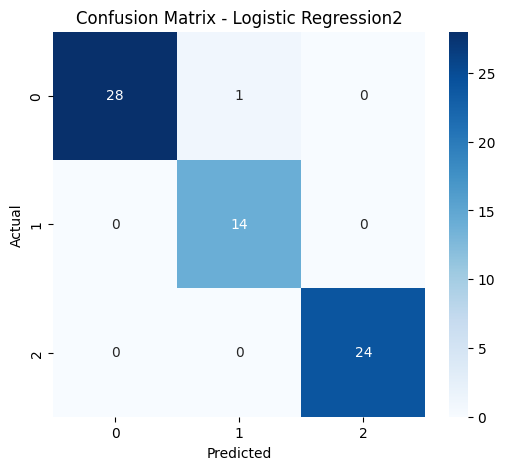

Best Parameters:
{'model__C': 1, 'model__solver': 'lbfgs'}


In [ ]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['lbfgs', 'liblinear']
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

best_model = evaluate_model2(
    "Logistic Regression2",
    grid_search
)

print("Best Parameters:")
print(grid_search.best_params_)

## Decision Tree

===== Decision Tree2 =====
Accuracy: 0.9552238805970149

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.97      0.95        29
           1       0.93      1.00      0.97        14
           2       1.00      0.92      0.96        24

    accuracy                           0.96        67
   macro avg       0.96      0.96      0.96        67
weighted avg       0.96      0.96      0.96        67



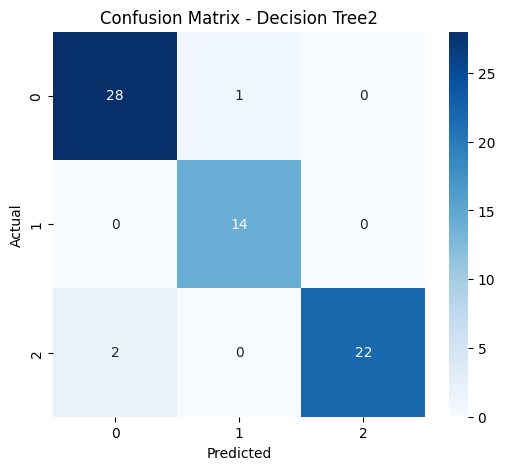

Best Parameters:
{'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_split': 2}


In [ ]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        random_state=42
    ))
])

param_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [None, 3, 5, 10],
    'model__min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

best_model = evaluate_model2(
    "Decision Tree2",
    grid_search
)

print("Best Parameters:")
print(grid_search.best_params_)

## Random Forest

===== Random Forest2 =====
Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



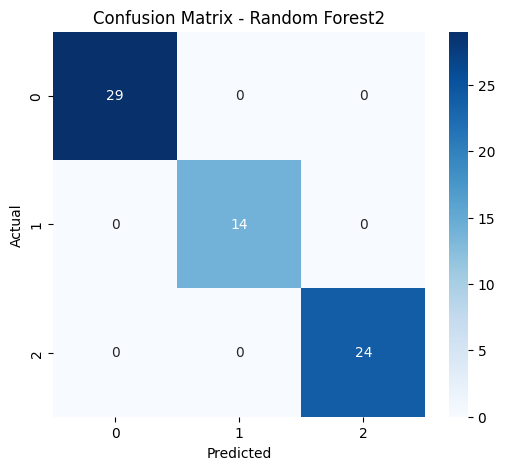

Best Parameters:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [ ]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42
    ))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

best_model = evaluate_model2(
    "Random Forest2",
    grid_search
)

print("Best Parameters:")
print(grid_search.best_params_)

## Support Vector machine

===== SVM2 =====
Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



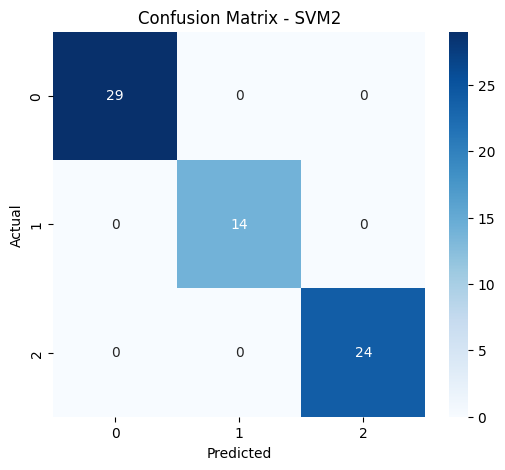

Best Parameters:
{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}


In [ ]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVC())
])

param_grid = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

best_model = evaluate_model2(
    "SVM2",
    grid_search
)

print("Best Parameters:")
print(grid_search.best_params_)

## Stochastic Gradient Descent

===== SGD Classifier2 =====
Accuracy: 0.9850746268656716

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.93      1.00      0.97        14
           2       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



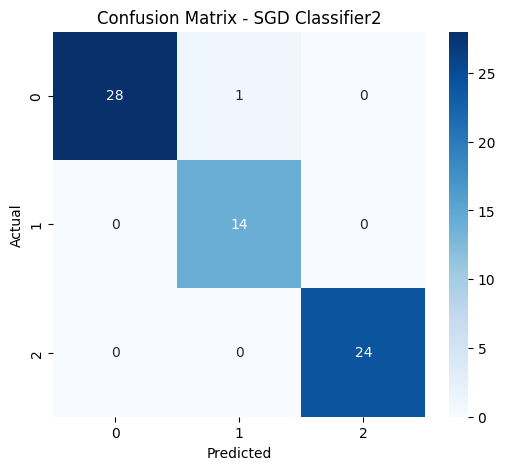

Best Parameters:
{'model__alpha': 0.001, 'model__loss': 'hinge'}


In [ ]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SGDClassifier(
        random_state=42
    ))
])

param_grid = {
    'model__loss': ['hinge', 'log_loss'],
    'model__alpha': [0.0001, 0.001, 0.01]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

best_model = evaluate_model2(
    "SGD Classifier2",
    grid_search
)

print("Best Parameters:")
print(grid_search.best_params_)

## Model Comparison

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='Model'
)

results_df

,Model,Accuracy
1,Decision Tree,0.955224
6,Decision Tree2,0.955224
0,Logistic Regression,0.985075
5,Logistic Regression2,0.985075
2,Random Forest,1.000000
7,Random Forest2,1.000000
4,SGD Classifier,1.000000
9,SGD Classifier2,0.985075
3,SVM,1.000000
8,SVM2,1.000000


Conclusion:
The hypothesis was partially confirmed.

Random Forest and SVM — hypothesis confirmed: both versions scored accuracy = 1.0, meaning removing body_mass_g did not worsen the results.

Logistic Regression — hypothesis confirmed: accuracy remained identical (0.985) in both versions.

Decision Tree — hypothesis confirmed: accuracy remained identical (0.955) in both versions.

SGD Classifier — hypothesis not confirmed: accuracy dropped from 1.0 to 0.985 after removing body_mass_g, meaning this feature carried useful information for SGD.

Overall, for 4 out of 5 models removing body_mass_g had no negative impact, which supports the idea that flipper_length_mm alone contains sufficient information (since the two features are highly correlated). However, the SGD Classifier proved sensitive to this change, showing that even highly correlated features can still contribute differently depending on the algorithm.